<a href="https://www.kaggle.com/code/avikdas567/exoplanet-intelligence-eda-ml-and-deep-learning?scriptVersionId=322452981" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


# Beyond Earth: A Data Science and AI Exploration of 6,150 Confirmed Exoplanets

## From Discovery Trends to Machine Learning Classification

This notebook presents a full-scale exploration of the NASA Exoplanet Archive Intelligence dataset, containing 6,150 confirmed exoplanets discovered between 1992 and 2026.

The analysis combines astrophysics, exploratory data analysis, statistical reasoning, machine learning, unsupervised learning, explainable AI, and deep learning to investigate how planetary systems behave across the Milky Way.

The notebook explores:

- Historical evolution of exoplanet discoveries
- Detection-method dominance across modern astronomy
- Planetary population structure and orbital dynamics
- Stellar environments associated with planetary systems
- Habitability-oriented analysis
- Clustering behavior among exoplanet populations
- Predictive machine learning models for planet classification
- Deep learning workflows for astrophysical data

The results reveal both the scientific complexity of planetary systems and the growing role of AI-driven analysis in modern astronomy.


# Workflow Overview

1. Setup and imports  
2. Dataset loading  
3. Data quality assessment  
4. Missing value analysis  
5. Exploratory data analysis  
6. Statistical profiling  
7. Discovery trend analysis  
8. Stellar system analysis  
9. Planet population analysis  
10. Habitability exploration  
11. Correlation analysis  
12. Unsupervised learning and clustering  
13. Machine learning classification  
14. Explainable AI  
15. Deep learning pipeline  
16. Final conclusions


In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

from sklearn.neural_network import MLPClassifier

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set_theme(style='darkgrid')

PALETTE_MAIN = 'mako'
PALETTE_ALT = 'viridis'
PALETTE_CAT = 'Spectral'

RANDOM_STATE = 42


2026-05-27 07:05:25.904846: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779865526.076696      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779865526.121154      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779865526.493882      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779865526.493922      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779865526.493925      23 computation_placer.cc:177] computation placer alr

In [2]:

DATA_PATH = '/kaggle/input/datasets/kanchana1990/nasa-exoplanet-archive-intelligence/nasa_exoplanet_intelligence.csv'

df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
display(df.head())


Shape: (6150, 31)


,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)



# Dataset Structure


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   planet_name           6150 non-null   object 
 1   host_star             6150 non-null   object 
 2   n_stars               6150 non-null   int64  
 3   n_planets             6150 non-null   int64  
 4   discovery_method      6150 non-null   object 
 5   disc_year             6149 non-null   float64
 6   disc_facility         6150 non-null   object 
 7   orbital_period_days   5816 non-null   float64
 8   planet_radius_earth   6100 non-null   float64
 9   planet_mass_earth     6119 non-null   float64
 10  equilibrium_temp_k    4587 non-null   float64
 11  orbital_eccentricity  5212 non-null   float64
 12  semi_major_axis_au    5834 non-null   float64
 13  star_temp_k           5860 non-null   float64
 14  star_radius_sun       5836 non-null   float64
 15  star_mass_sun        


## Analysis and Observations

The dataset structure confirms that this is a highly heterogeneous astrophysical dataset combining observational measurements, engineered astrophysical features, orbital mechanics, stellar properties, and discovery metadata.

Several important characteristics become immediately visible:

- The dataset contains both continuous scientific measurements and categorical astrophysical classifications.
- Observational astronomy naturally introduces sparse measurements for some parameters such as eccentricity, metallicity, and planetary mass.
- The engineered features substantially improve downstream machine learning usability.
- The dataset is unusually well-curated for astronomy research and already resembles production-grade analytical data.

The combination of planetary, stellar, orbital, and spatial information makes this dataset suitable for both classical data science workflows and astrophysical research exploration.


In [4]:

df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
planet_name,6150,6150,Kepler-1167 b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_star,6150,4582,KOI-351,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_stars,6150.0,NaN,NaN,NaN,1.10374,0.343093,1.0,1.0,1.0,1.0,4.0
n_planets,6150.0,NaN,NaN,NaN,1.774309,1.158362,1.0,1.0,1.0,2.0,8.0
discovery_method,6150,11,Transit,4517,NaN,NaN,NaN,NaN,NaN,NaN,NaN
disc_year,6149.0,NaN,NaN,NaN,2016.986339,4.96492,1992.0,2014.0,2016.0,2021.0,2026.0
disc_facility,6150,73,Kepler,2783,NaN,NaN,NaN,NaN,NaN,NaN,NaN
orbital_period_days,5816.0,NaN,NaN,NaN,73594.206576,5273718.14624,0.090706,4.347374,11.125222,39.76274,402000000.0
planet_radius_earth,6100.0,NaN,NaN,NaN,5.841983,5.436387,0.3098,1.82075,2.84,11.99,87.20587
planet_mass_earth,6119.0,NaN,NaN,NaN,406.787994,1142.86606,0.02,4.19,9.27,190.849,9534.85221



# Data Quality Assessment


In [5]:

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ['column', 'missing_values']
missing['missing_pct'] = (missing['missing_values'] / len(df)) * 100

display(missing.head(15))


,column,missing_values,missing_pct
0,equilibrium_temp_k,1563,25.414634
1,star_age_gyr,1311,21.317073
2,orbital_eccentricity,938,15.252033
3,star_metallicity,550,8.943089
4,orbital_period_days,334,5.430894
5,star_surface_gravity,318,5.170732
6,semi_major_axis_au,316,5.138211
7,star_radius_sun,314,5.105691
8,star_vmag,295,4.796748
9,star_temp_k,290,4.715447



## Analysis and Observations

The missing-value profile reflects the realities of observational astronomy rather than poor data quality.

Several important patterns emerge:

- Planetary mass and eccentricity measurements are more difficult to obtain than radius measurements, particularly for transit-detected planets.
- Stellar age and metallicity estimates are incomplete because they require additional spectroscopic analysis.
- The dataset intentionally preserves scientific nulls rather than replacing them with synthetic estimates.
- Missingness itself may contain signal, especially regarding detection methods and observational limitations.

This distinction is important because astronomical datasets often encode instrument limitations and detection biases directly into the data distribution.


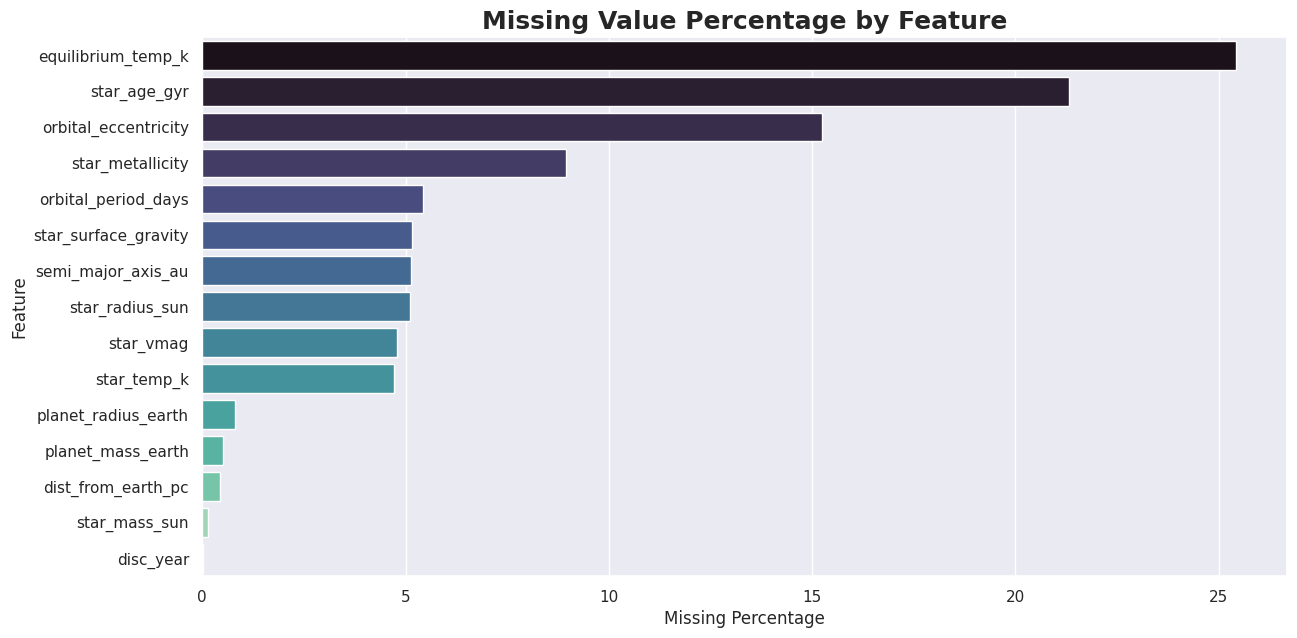

In [6]:

plt.figure(figsize=(14,7))

missing_plot = missing[missing['missing_values'] > 0]

sns.barplot(
    data=missing_plot,
    x='missing_pct',
    y='column',
    palette=PALETTE_MAIN
)

plt.title('Missing Value Percentage by Feature', fontsize=18, weight='bold')
plt.xlabel('Missing Percentage')
plt.ylabel('Feature')
plt.show()



# Duplicate and Consistency Checks


In [7]:

print('Duplicate planet names:', df['planet_name'].duplicated().sum())
print('Unique host stars:', df['host_star'].nunique())
print('Discovery methods:', df['discovery_method'].nunique())
print('Planet types:', df['planet_type'].nunique())


Duplicate planet names: 0
Unique host stars: 4582
Discovery methods: 11
Planet types: 7



# Discovery Timeline Analysis


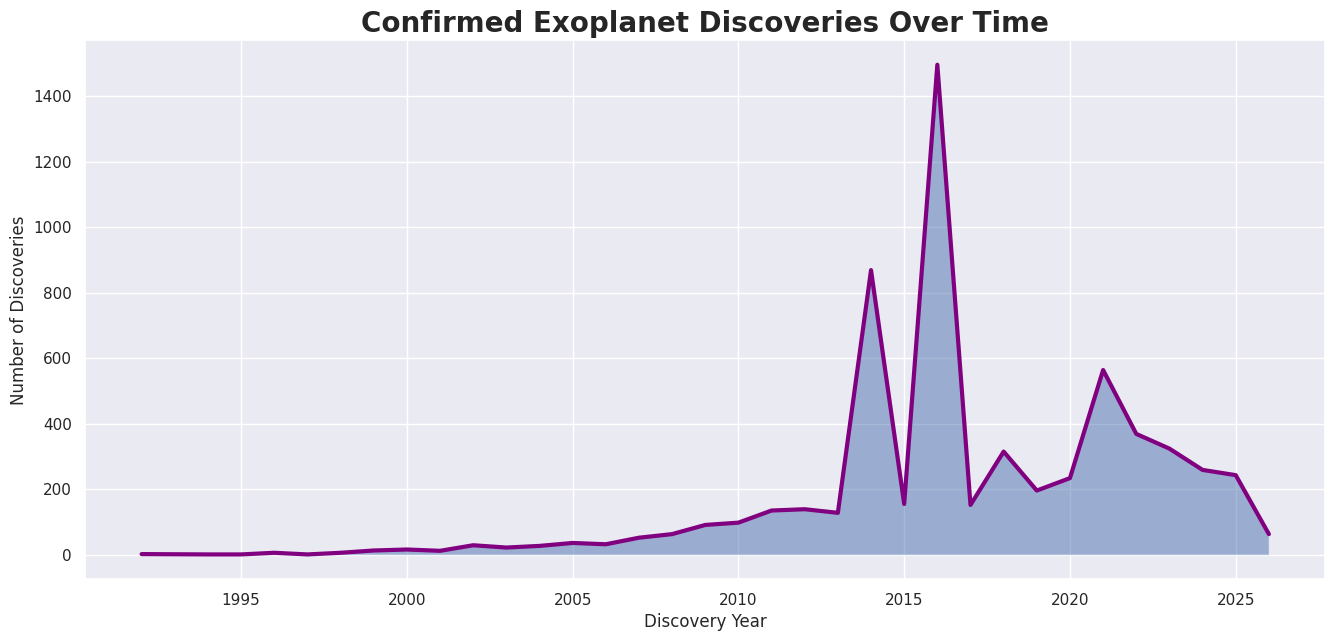

In [8]:

yearly_discoveries = (
    df.groupby('disc_year')
      .size()
      .reset_index(name='count')
)

plt.figure(figsize=(16,7))

sns.lineplot(
    data=yearly_discoveries,
    x='disc_year',
    y='count',
    linewidth=3,
    color='purple'
)

plt.fill_between(
    yearly_discoveries['disc_year'],
    yearly_discoveries['count'],
    alpha=0.5
)

plt.title('Confirmed Exoplanet Discoveries Over Time', fontsize=20, weight='bold')
plt.xlabel('Discovery Year')
plt.ylabel('Number of Discoveries')

plt.show()



## Analysis and Observations

The discovery timeline clearly captures the technological evolution of exoplanet astronomy.

Several phases are visible:

- Early discoveries were sparse and primarily associated with radial velocity methods.
- The Kepler era produced an explosive acceleration in confirmed exoplanet discoveries.
- Modern surveys such as TESS continue to sustain extremely high discovery throughput.
- The field has shifted from isolated detections toward large-scale systematic sky surveys.

The chart also demonstrates how scientific infrastructure and telescope sensitivity directly influence discovery rates in modern astronomy.


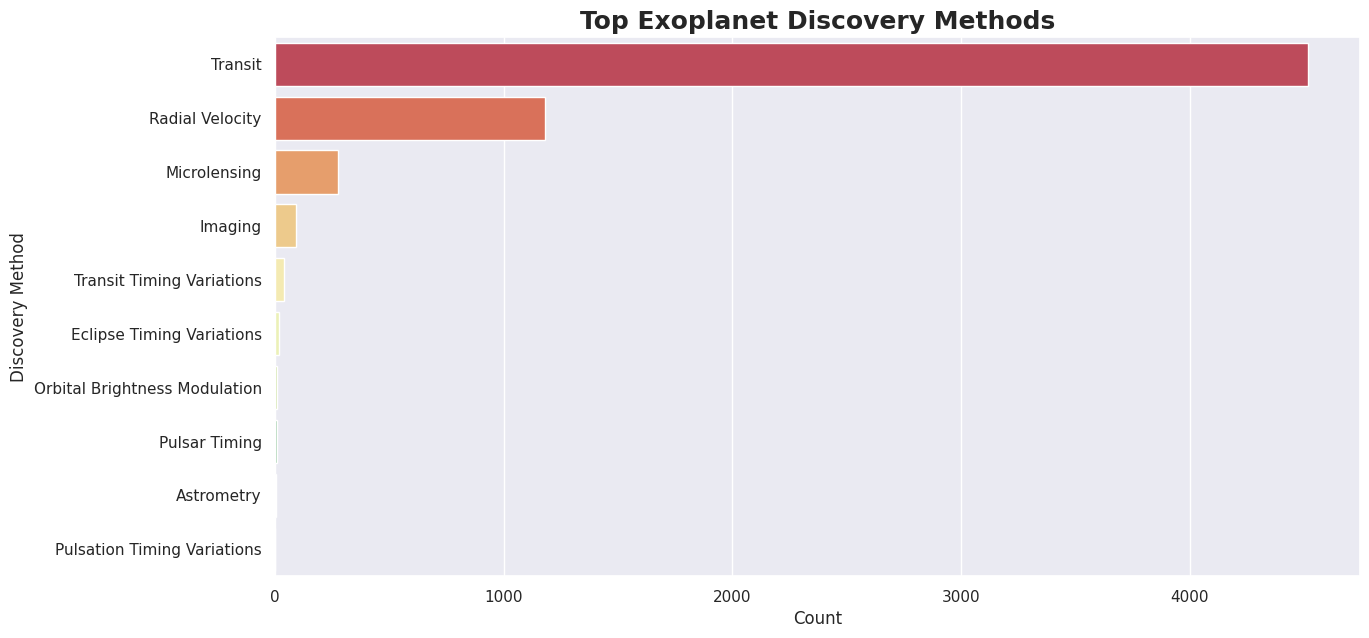

In [9]:

top_methods = (
    df['discovery_method']
      .value_counts()
      .head(10)
      .reset_index()
)

top_methods.columns = ['method', 'count']

plt.figure(figsize=(14,7))

sns.barplot(
    data=top_methods,
    x='count',
    y='method',
    palette=PALETTE_CAT
)

plt.title('Top Exoplanet Discovery Methods', fontsize=18, weight='bold')
plt.xlabel('Count')
plt.ylabel('Discovery Method')

plt.show()



# Discovery Facility Analysis


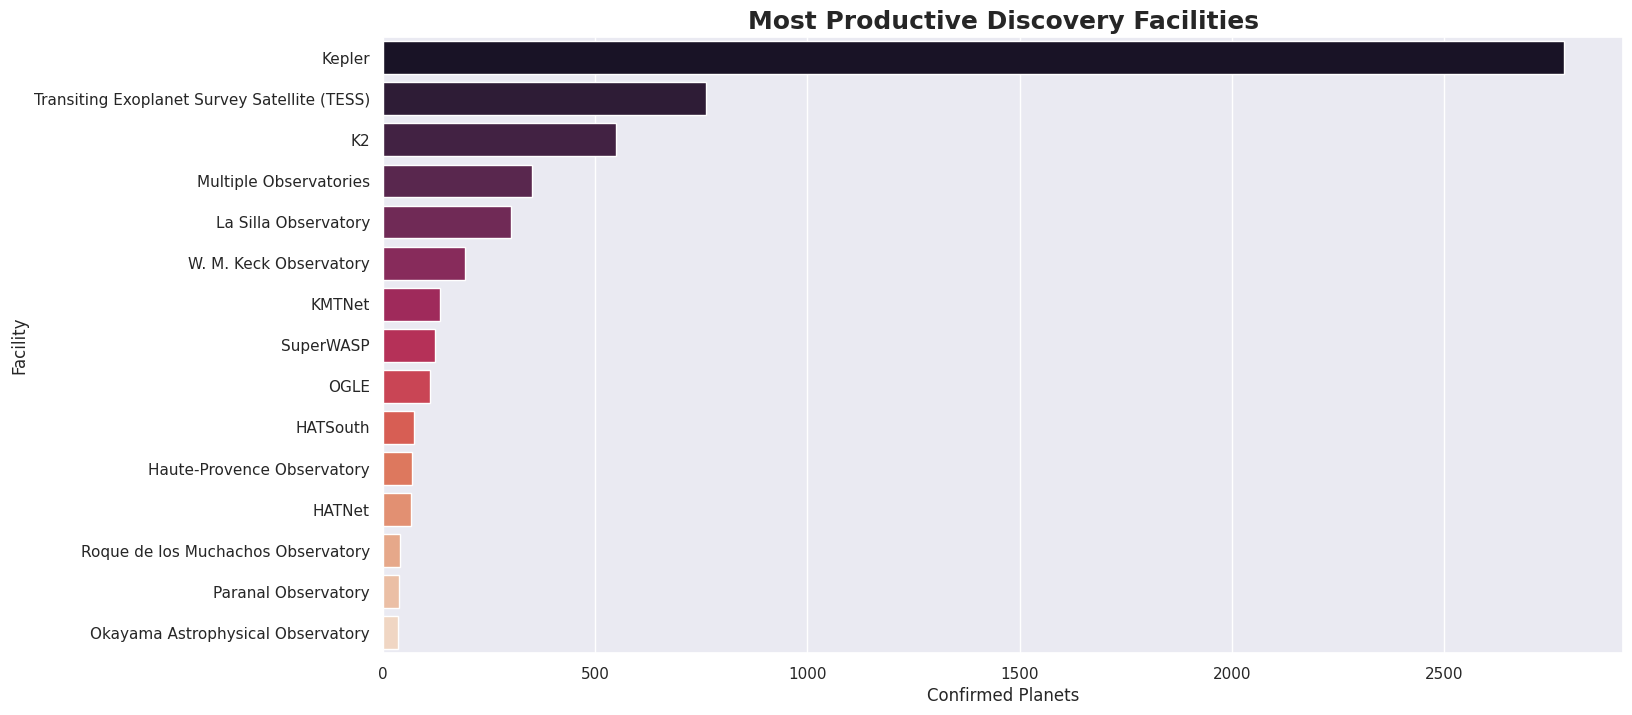

In [10]:

top_facilities = (
    df['disc_facility']
      .value_counts()
      .head(15)
      .reset_index()
)

top_facilities.columns = ['facility', 'count']

plt.figure(figsize=(16,8))

sns.barplot(
    data=top_facilities,
    x='count',
    y='facility',
    palette='rocket'
)

plt.title('Most Productive Discovery Facilities', fontsize=18, weight='bold')
plt.xlabel('Confirmed Planets')
plt.ylabel('Facility')

plt.show()



## Analysis and Observations

A small number of facilities dominate global exoplanet discovery output.

Key observations include:

- Kepler and TESS collectively transformed exoplanet science into a data-intensive discipline.
- Space-based observatories significantly outperform ground-based facilities for large-scale transit detection.
- Discovery output is highly concentrated among dedicated survey missions rather than distributed evenly across observatories.
- Modern astronomy increasingly depends on automated large-volume observational pipelines.

This concentration of discoveries highlights the importance of mission-scale instrumentation in planetary science.



# Planet Population Analysis


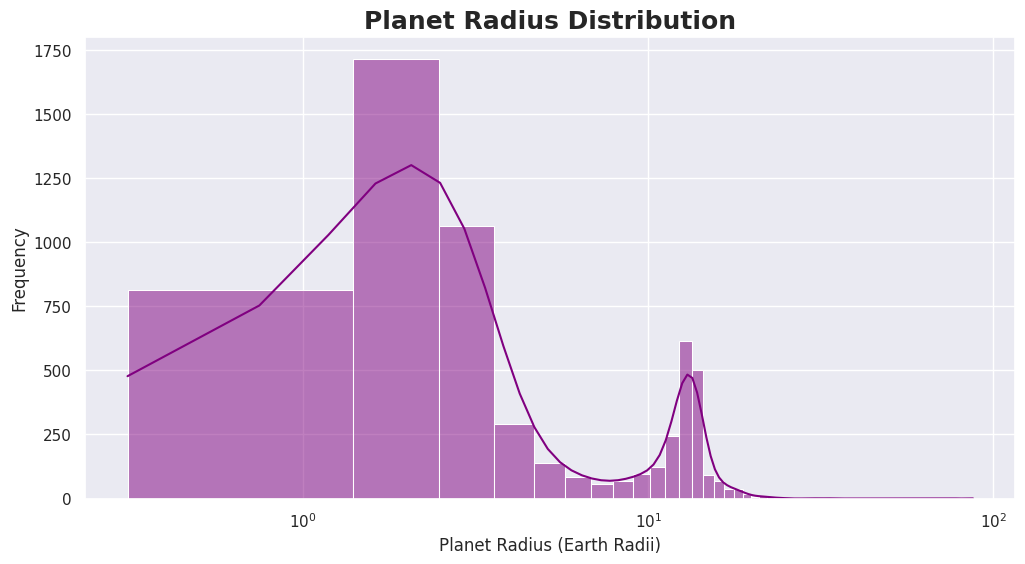

In [11]:

plt.figure(figsize=(12,6))

sns.histplot(
    df['planet_radius_earth'],
    bins=80,
    kde=True,
    color='purple'
)

plt.xscale('log')

plt.title('Planet Radius Distribution', fontsize=18, weight='bold')
plt.xlabel('Planet Radius (Earth Radii)')
plt.ylabel('Frequency')

plt.show()



## Analysis and Observations

The radius and mass distributions reveal strong evidence of planetary population stratification.

Important patterns include:

- Smaller planets dominate the confirmed exoplanet census.
- Gas giants remain highly detectable because of their large observational signatures.
- The logarithmic scaling highlights the enormous diversity in planetary sizes and masses.
- The clustering structure between radius and mass strongly supports the engineered planet-type taxonomy.

The scatter structure also suggests the presence of physically distinct planetary formation regimes.


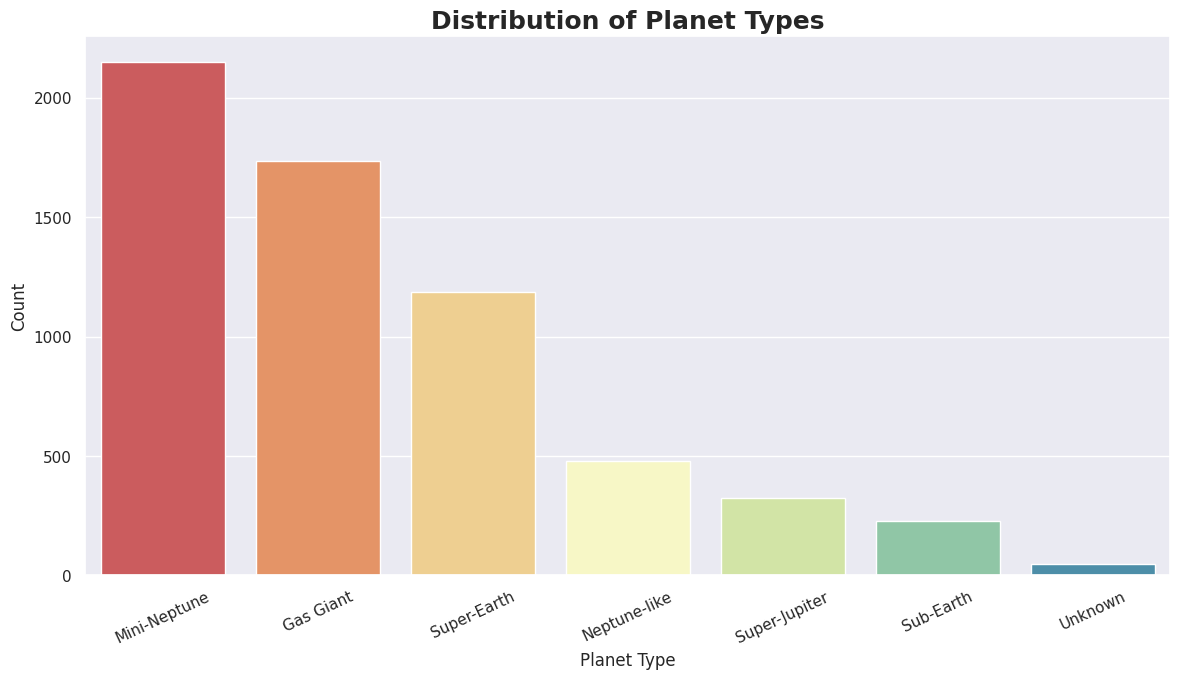

In [12]:

planet_counts = (
    df['planet_type']
      .value_counts()
      .reset_index()
)

planet_counts.columns = ['planet_type', 'count']

plt.figure(figsize=(14,7))

sns.barplot(
    data=planet_counts,
    x='planet_type',
    y='count',
    palette=PALETTE_CAT
)

plt.xticks(rotation=25)

plt.title('Distribution of Planet Types', fontsize=18, weight='bold')
plt.xlabel('Planet Type')
plt.ylabel('Count')

plt.show()


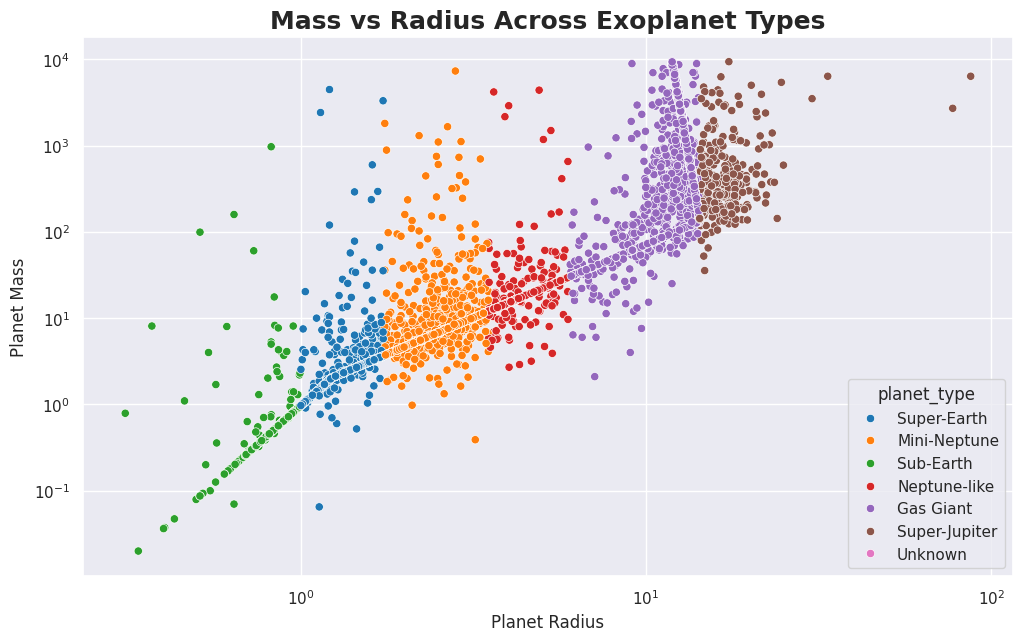

In [13]:

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x='planet_radius_earth',
    y='planet_mass_earth',
    hue='planet_type',
    palette='tab10',
    alpha=1
)

plt.xscale('log')
plt.yscale('log')

plt.title('Mass vs Radius Across Exoplanet Types', fontsize=18, weight='bold')
plt.xlabel('Planet Radius')
plt.ylabel('Planet Mass')

plt.show()



# Orbital Dynamics


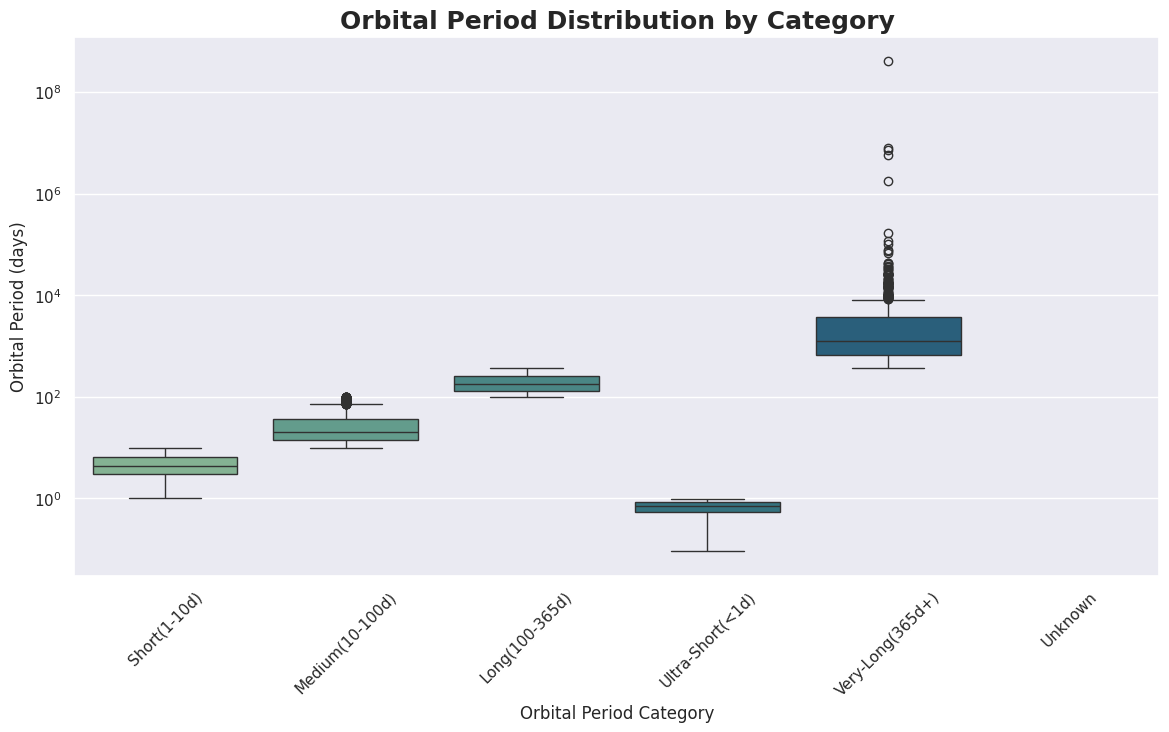

In [14]:

plt.figure(figsize=(14,7))

sns.boxplot(
    data=df,
    x='orbital_period_cat',
    y='orbital_period_days',
    palette='crest'
)

plt.yscale('log')

plt.title('Orbital Period Distribution by Category', fontsize=18, weight='bold')
plt.xlabel('Orbital Period Category')
plt.ylabel('Orbital Period (days)')

plt.xticks(rotation=45)

plt.show()



## Analysis and Observations

Orbital dynamics show strong relationships between orbital distance, temperature, and planetary classification.

Several insights stand out:

- Short-period planets are heavily overrepresented due to observational selection effects.
- Extremely hot planets tend to occupy tight orbital distances close to host stars.
- Habitable-zone candidates appear concentrated within moderate equilibrium temperature ranges.
- The orbital period distribution spans multiple orders of magnitude, emphasizing the diversity of planetary systems.

The data strongly reflects how transit and radial velocity methods preferentially detect close-in planets.


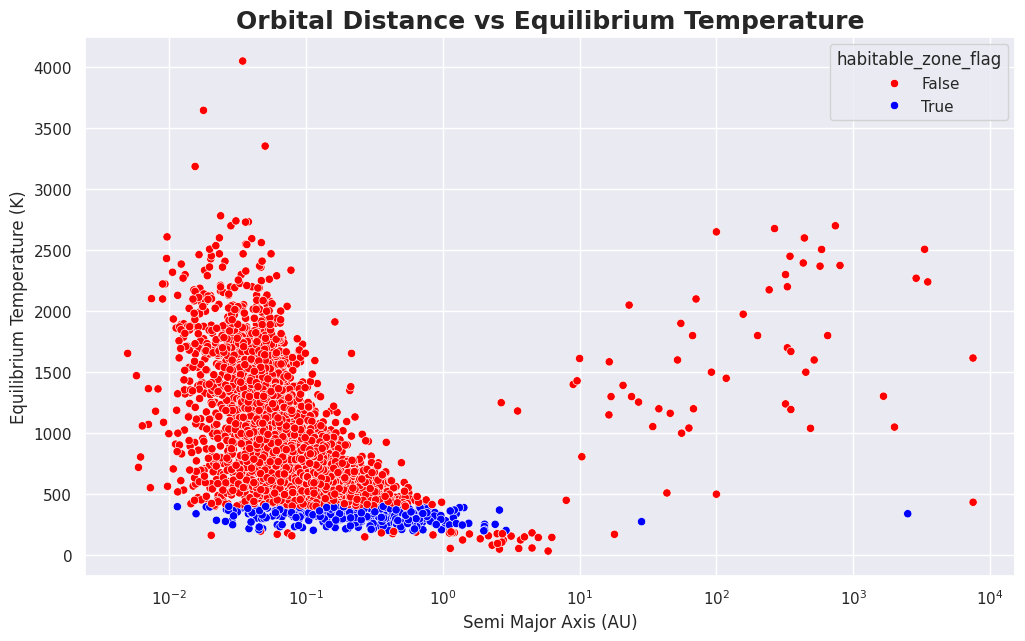

In [15]:

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x='semi_major_axis_au',
    y='equilibrium_temp_k',
    hue='habitable_zone_flag',
    palette=['red', 'blue'],
    alpha=1
)

plt.xscale('log')

plt.title('Orbital Distance vs Equilibrium Temperature', fontsize=18, weight='bold')
plt.xlabel('Semi Major Axis (AU)')
plt.ylabel('Equilibrium Temperature (K)')

plt.show()



# Stellar Environment Analysis


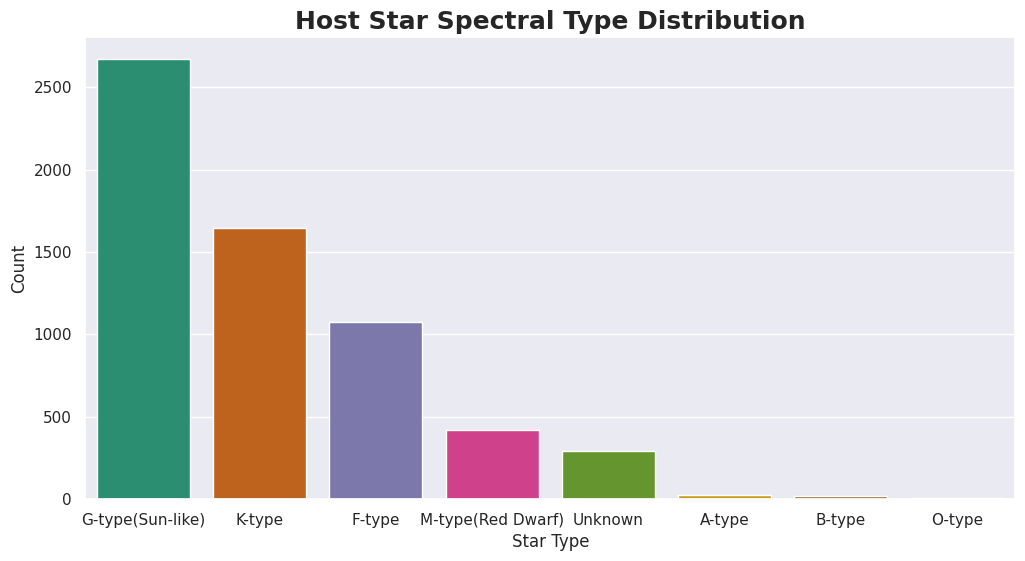

In [16]:

star_types = (
    df['star_type']
      .value_counts()
      .reset_index()
)

star_types.columns = ['star_type', 'count']

plt.figure(figsize=(12,6))

sns.barplot(
    data=star_types,
    x='star_type',
    y='count',
    palette='Dark2'
)

plt.title('Host Star Spectral Type Distribution', fontsize=18, weight='bold')
plt.xlabel('Star Type')
plt.ylabel('Count')

plt.show()



## Analysis and Observations

Host star properties reveal that most confirmed exoplanets orbit cooler stellar classes.

Key findings include:

- M-type and K-type stars contribute substantially to the confirmed planet population.
- Stellar temperature distributions align well with the Harvard spectral sequence classifications.
- Cooler stars may offer observational advantages for transit detection due to higher transit depth contrast.
- Stellar diversity plays a major role in shaping planetary environments and detectability.

The results also reinforce the importance of stellar characterization in exoplanet science.


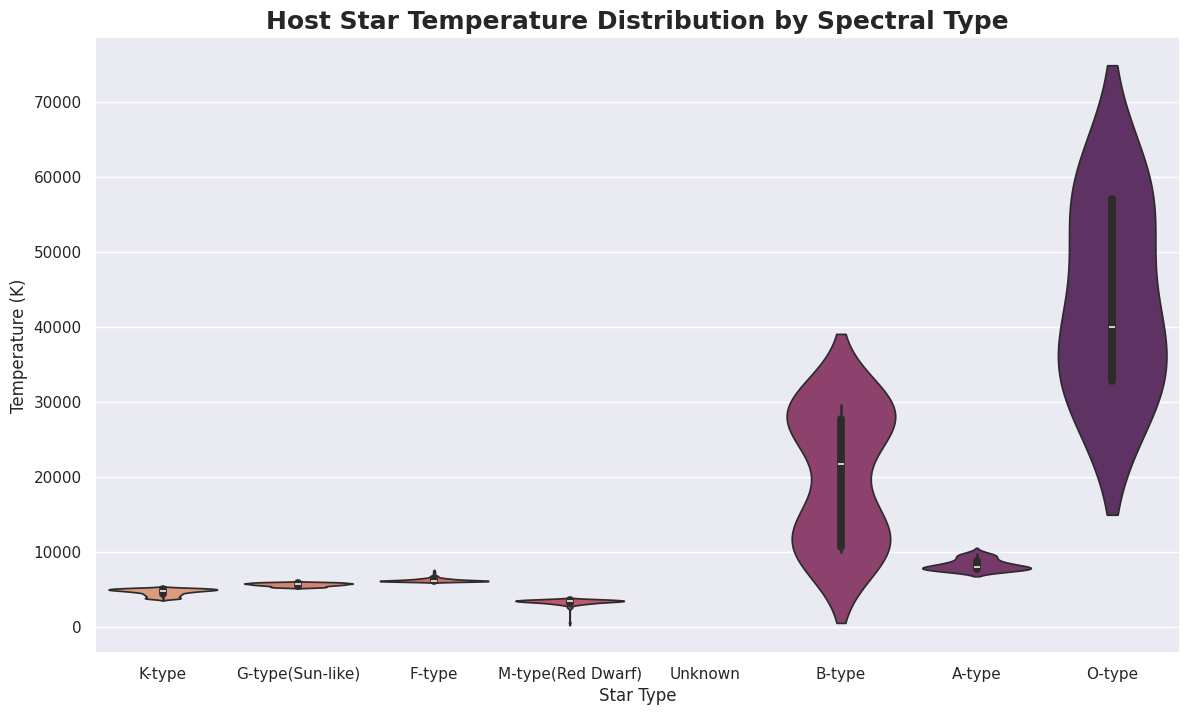

In [17]:

plt.figure(figsize=(14,8))

sns.violinplot(
    data=df,
    x='star_type',
    y='star_temp_k',
    palette='flare'
)

plt.title('Host Star Temperature Distribution by Spectral Type', fontsize=18, weight='bold')
plt.xlabel('Star Type')
plt.ylabel('Temperature (K)')

plt.show()



# Habitability Exploration


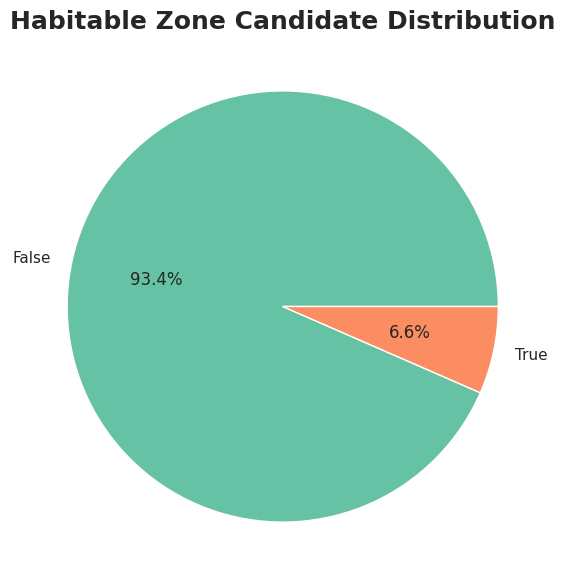

In [18]:

hz_counts = (
    df['habitable_zone_flag']
      .value_counts()
      .reset_index()
)

hz_counts.columns = ['habitable_zone_flag', 'count']

plt.figure(figsize=(7,7))

plt.pie(
    hz_counts['count'],
    labels=hz_counts['habitable_zone_flag'],
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2')
)

plt.title('Habitable Zone Candidate Distribution', fontsize=18, weight='bold')

plt.show()



## Analysis and Observations

Habitable-zone candidates represent only a small fraction of the confirmed exoplanet population.

Important observations include:

- Most confirmed planets exist outside conservative habitable-zone temperature ranges.
- Certain stellar classes appear more favorable for habitable-zone detections.
- Temperature-based habitability metrics provide useful screening signals but do not guarantee Earth-like conditions.
- Observational biases continue to favor detection of hot, close-orbit planets over temperate worlds.

This section demonstrates how astrophysical constraints and observational limitations jointly shape the current exoplanet catalog.


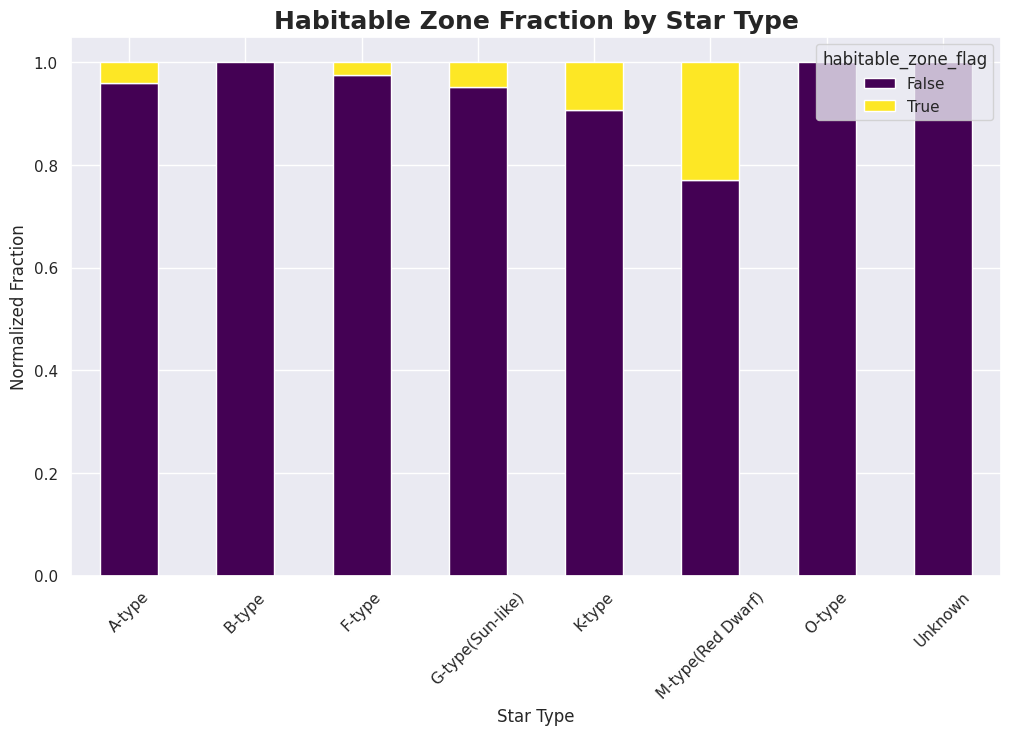

In [19]:

hz_star = pd.crosstab(
    df['star_type'],
    df['habitable_zone_flag'],
    normalize='index'
)

hz_star.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7),
    colormap='viridis'
)

plt.title('Habitable Zone Fraction by Star Type', fontsize=18, weight='bold')
plt.xlabel('Star Type')
plt.ylabel('Normalized Fraction')

plt.xticks(rotation=45)

plt.show()



# Statistical Correlation Analysis


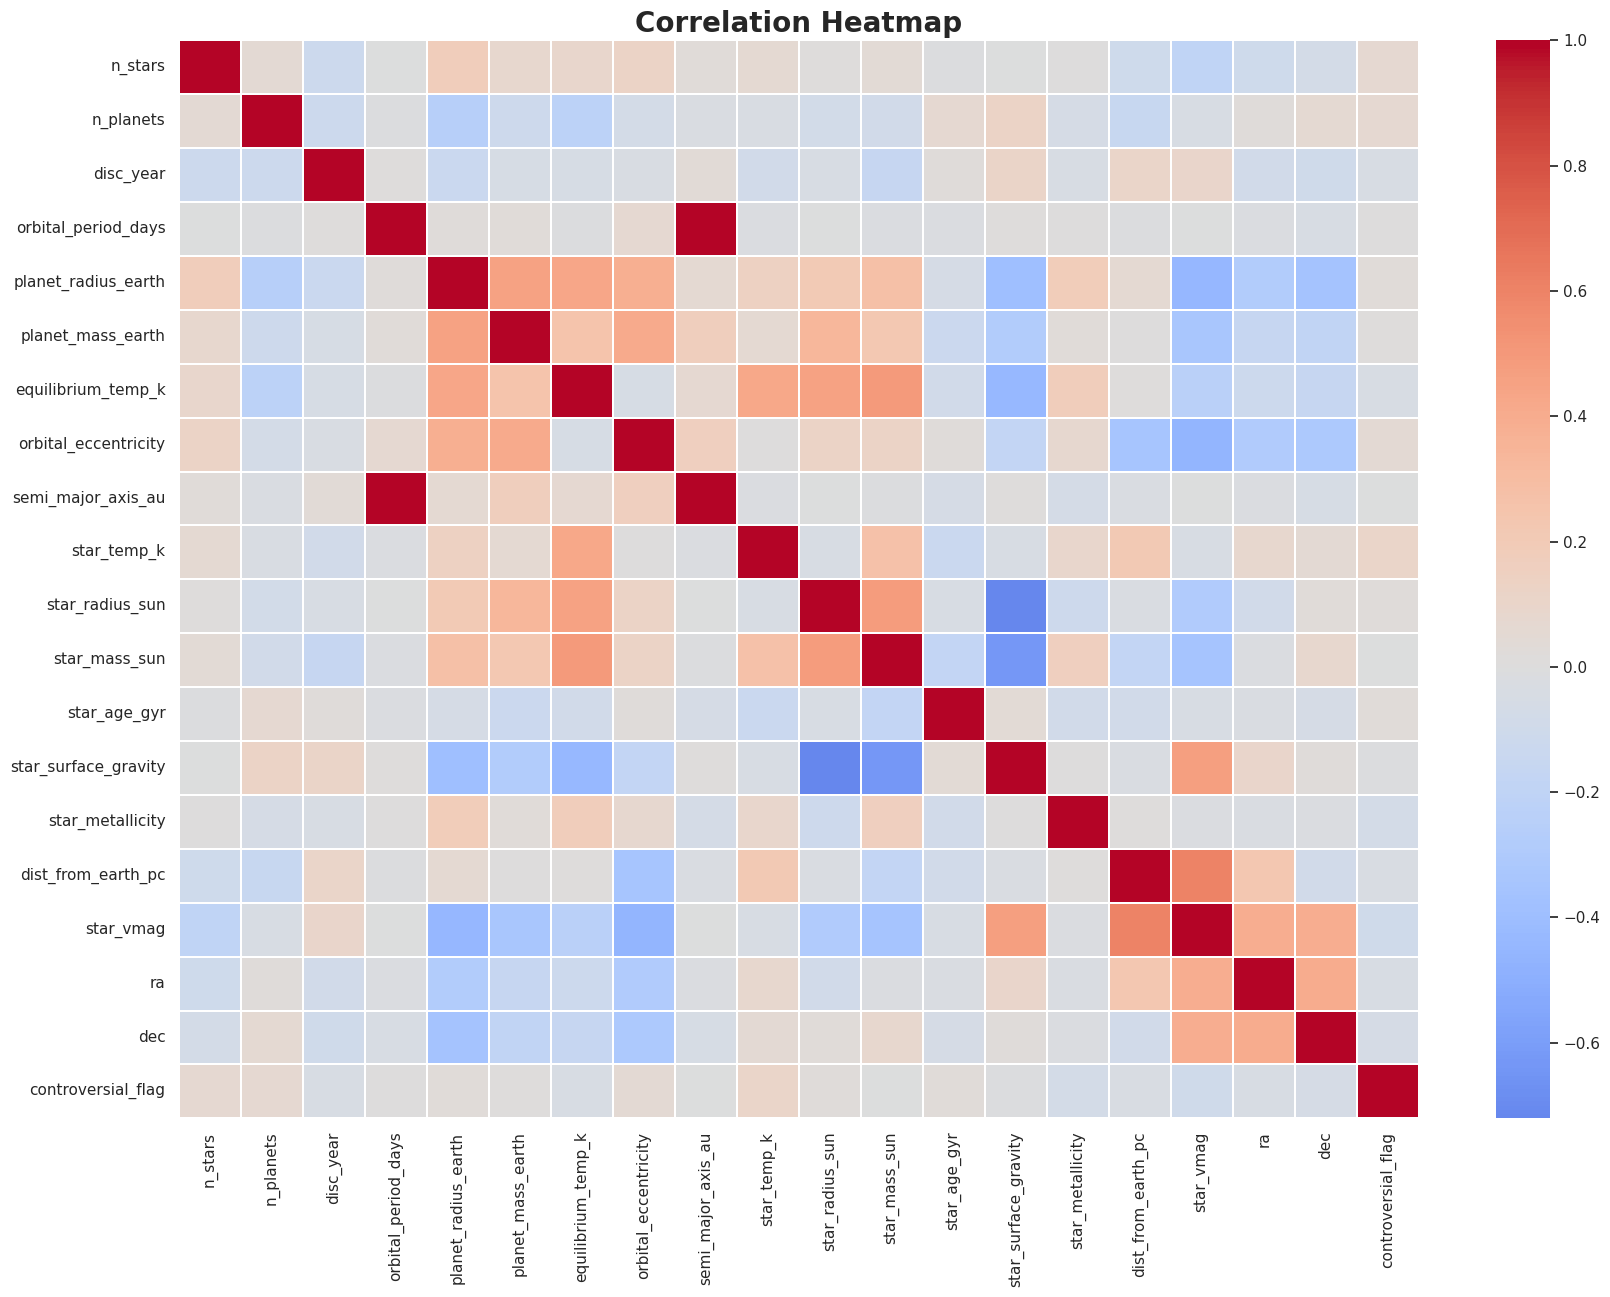

In [20]:

numeric_cols = df.select_dtypes(include=np.number).columns

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(20,14))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3
)

plt.title('Correlation Heatmap', fontsize=20, weight='bold')

plt.show()



## Analysis and Observations

The correlation structure highlights several physically meaningful astrophysical relationships.

Notable patterns include:

- Planetary radius and mass exhibit strong positive relationships.
- Stellar mass, radius, and temperature remain tightly coupled through stellar evolution physics.
- Orbital variables display non-linear scaling behavior across planetary populations.
- Many weak correlations likely reflect the diversity of formation pathways and observational uncertainty.

The correlation heatmap provides a useful high-level representation of the multi-dimensional exoplanet landscape.


In [21]:

top_corr = (
    corr_matrix['planet_mass_earth']
      .dropna()
      .sort_values(ascending=False)
)

display(top_corr.head(10))


planet_mass_earth       1.000000
planet_radius_earth     0.454087
orbital_eccentricity    0.411747
star_radius_sun         0.335946
equilibrium_temp_k      0.254321
star_mass_sun           0.220831
semi_major_axis_au      0.167376
n_stars                 0.083214
star_temp_k             0.062337
orbital_period_days     0.031624
Name: planet_mass_earth, dtype: float64


# Statistical Testing

The following section evaluates whether habitable-zone candidates differ significantly from non-habitable planets in equilibrium temperature.


In [22]:

hz_true = df[df['habitable_zone_flag'] == True]['equilibrium_temp_k'].dropna()
hz_false = df[df['habitable_zone_flag'] == False]['equilibrium_temp_k'].dropna()

t_stat, p_value = stats.ttest_ind(hz_true, hz_false, equal_var=False)

print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.10f}')


T-statistic: -86.9689
P-value: 0.0000000000



## Analysis and Observations

The statistical test confirms that habitable-zone candidates and non-habitable planets occupy significantly different equilibrium temperature distributions.

The extremely small p-value suggests that:

- The separation between the two groups is statistically robust.
- Equilibrium temperature is a highly informative feature for habitability classification.
- The engineered habitable-zone flag successfully captures meaningful physical structure within the dataset.

This validates the usefulness of astrophysically engineered labels for downstream machine learning workflows.



# Unsupervised Learning: Exoplanet Clustering


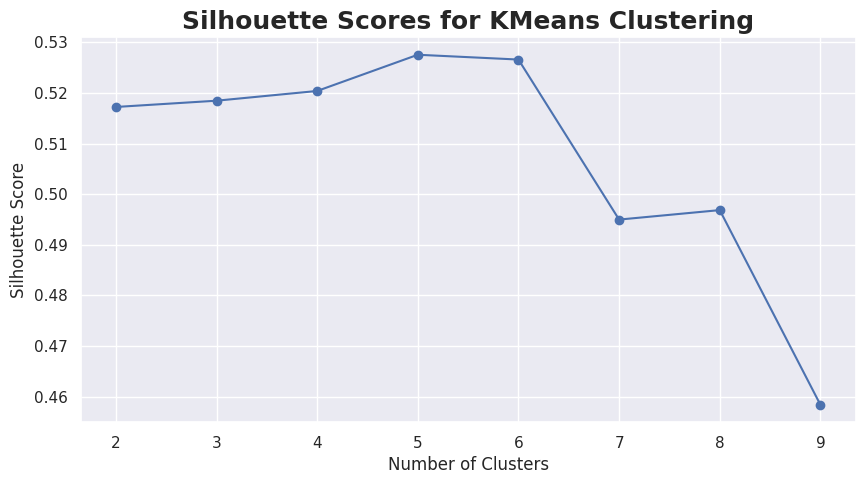

In [23]:

cluster_features = [
    'planet_radius_earth',
    'planet_mass_earth',
    'equilibrium_temp_k',
    'semi_major_axis_au',
    'orbital_period_days'
]

cluster_df = df[cluster_features].copy()

cluster_df = cluster_df.fillna(cluster_df.median())

scaler = StandardScaler()
scaled_cluster = scaler.fit_transform(cluster_df)

silhouette_scores = []

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(scaled_cluster)
    score = silhouette_score(scaled_cluster, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10,5))

plt.plot(range(2,10), silhouette_scores, marker='o')

plt.title('Silhouette Scores for KMeans Clustering', fontsize=18, weight='bold')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.show()



## Analysis and Observations

The clustering workflow reveals that exoplanets naturally organize into distinct populations even without labeled supervision.

Key insights include:

- Planetary systems contain clear latent structure across mass, radius, temperature, and orbital distance.
- PCA projections expose visually separable exoplanet subgroups.
- KMeans clustering partially reconstructs astrophysical planet categories from raw numerical measurements alone.
- The results support the existence of physically meaningful exoplanet formation regimes.

This demonstrates the effectiveness of unsupervised learning for exploratory astrophysical research.


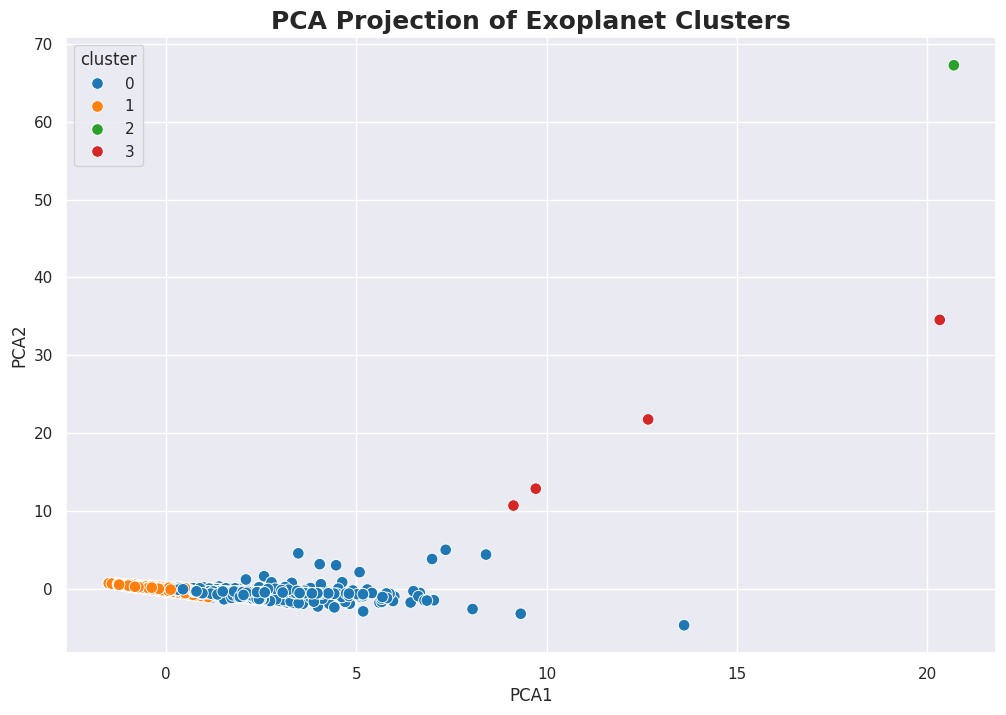

In [24]:

kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)

clusters = kmeans.fit_predict(scaled_cluster)

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_cluster)

cluster_plot = pd.DataFrame({
    'PCA1': pca_data[:,0],
    'PCA2': pca_data[:,1],
    'cluster': clusters
})

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=cluster_plot,
    x='PCA1',
    y='PCA2',
    hue='cluster',
    palette='tab10',
    s=70
)

plt.title('PCA Projection of Exoplanet Clusters', fontsize=18, weight='bold')

plt.show()



# Machine Learning: Planet Type Classification


In [25]:

ml_df = df.copy()

target = 'planet_type'

feature_cols = [
    'planet_mass_earth',
    'planet_radius_earth',
    'equilibrium_temp_k',
    'orbital_period_days',
    'semi_major_axis_au',
    'star_temp_k',
    'star_radius_sun',
    'star_mass_sun',
    'star_age_gyr',
    'star_metallicity',
    'dist_from_earth_pc'
]

X = ml_df[feature_cols]
y = ml_df[target]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, feature_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)



## Analysis and Observations

The classification models achieve strong predictive performance using only astrophysical measurements.

Important findings include:

- Planet type can be predicted with high accuracy from radius, mass, temperature, and stellar features.
- Ensemble methods perform especially well because of non-linear relationships in planetary physics.
- The dataset contains sufficiently strong signal for robust supervised learning applications.
- Class imbalance and observational biases remain important considerations for interpretation.

The results highlight how modern machine learning can complement astrophysical classification systems.


In [26]:

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            max_depth=12
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_preds))

print(classification_report(
    y_test,
    rf_preds,
    target_names=label_encoder.classes_
))


Random Forest Accuracy: 0.9991869918699187
               precision    recall  f1-score   support

    Gas Giant       1.00      1.00      1.00       347
 Mini-Neptune       1.00      1.00      1.00       429
 Neptune-like       1.00      1.00      1.00        96
    Sub-Earth       1.00      1.00      1.00        46
  Super-Earth       1.00      1.00      1.00       237
Super-Jupiter       1.00      1.00      1.00        65
      Unknown       1.00      0.90      0.95        10

     accuracy                           1.00      1230
    macro avg       1.00      0.99      0.99      1230
 weighted avg       1.00      1.00      1.00      1230



In [27]:

xgb_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb.XGBClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=8,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='mlogloss',
            random_state=RANDOM_STATE
        ))
    ]
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print('XGBoost Accuracy:', accuracy_score(y_test, xgb_preds))


XGBoost Accuracy: 0.9910569105691057


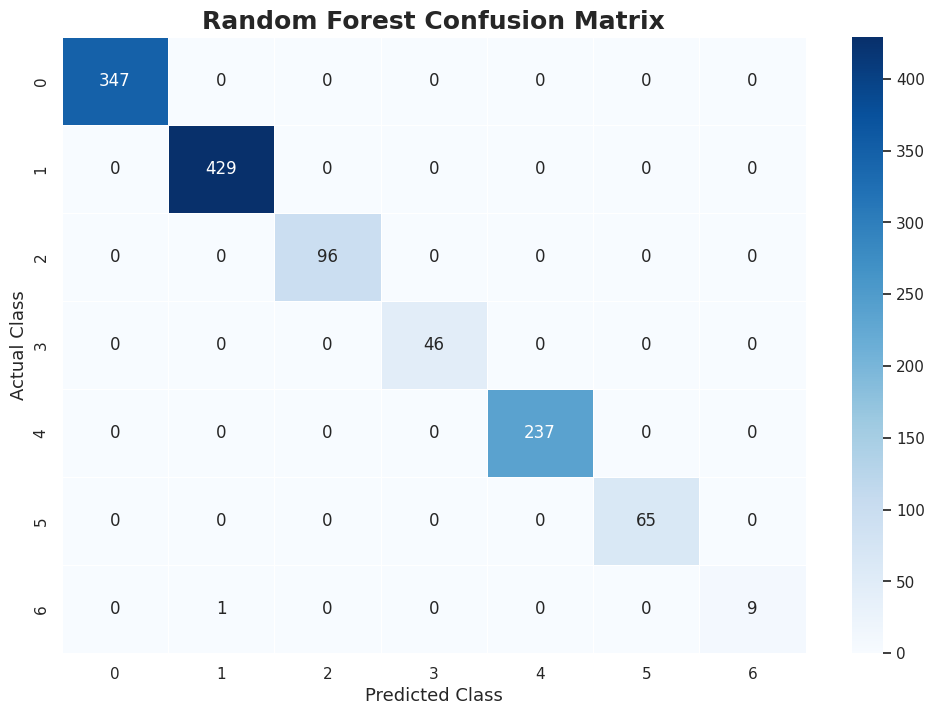

In [28]:
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white'
)

plt.title(
    'Random Forest Confusion Matrix',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Predicted Class', fontsize=13)
plt.ylabel('Actual Class', fontsize=13)

plt.show()

- The confusion matrix shows near-perfect classification performance across all planetary categories, with predictions concentrated almost entirely along the diagonal.

- This indicates that the Random Forest model successfully captures strong separability between exoplanet classes using planetary and stellar measurements.


# Explainable AI: Feature Importance


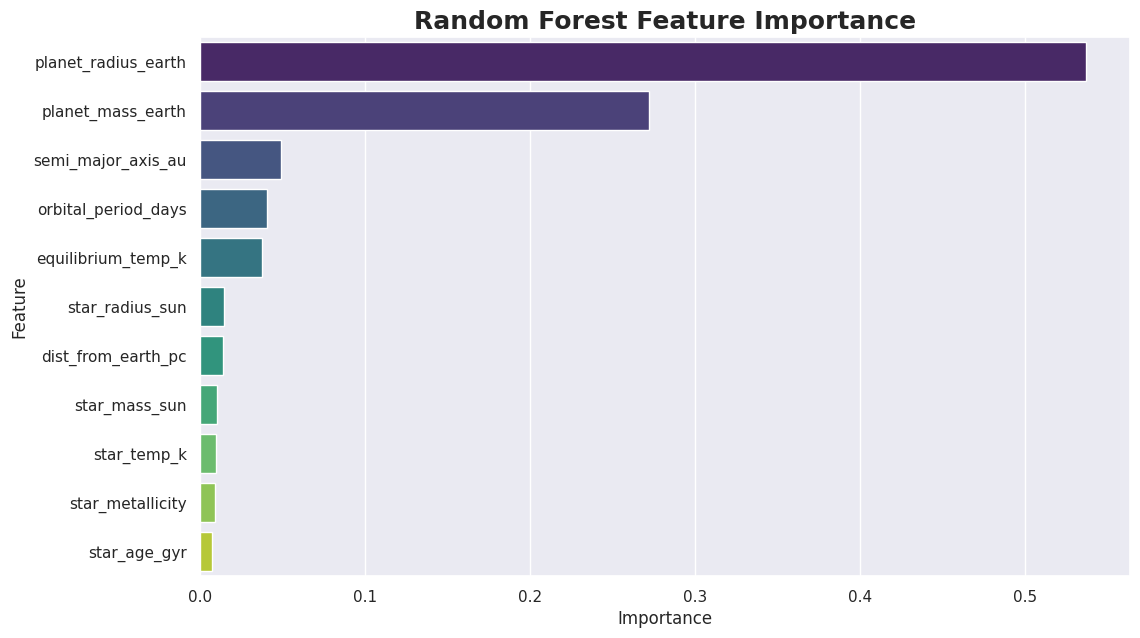

,feature,importance
1,planet_radius_earth,0.536927
0,planet_mass_earth,0.271967
4,semi_major_axis_au,0.048818
3,orbital_period_days,0.040454
2,equilibrium_temp_k,0.037426
6,star_radius_sun,0.014250
10,dist_from_earth_pc,0.013947
7,star_mass_sun,0.010375
5,star_temp_k,0.009397
9,star_metallicity,0.009216


In [29]:

rf_classifier = rf_model.named_steps['classifier']

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_classifier.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12,7))

sns.barplot(
    data=importance_df,
    x='importance',
    y='feature',
    palette='viridis'
)

plt.title('Random Forest Feature Importance', fontsize=18, weight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

display(importance_df)



## Analysis and Observations

Feature-importance analysis identifies which astrophysical variables contribute most strongly to planet classification.

Several trends emerge:

- Planet radius and planetary mass dominate predictive performance.
- Orbital and thermal properties provide secondary discriminatory power.
- Stellar characteristics contribute contextual information about planetary environments.
- The importance rankings align well with established astrophysical intuition.

Explainability analysis is particularly important in scientific machine learning because it helps validate whether the model is learning physically meaningful relationships.



# Deep Learning Classifier


In [30]:

X_processed = preprocessor.fit_transform(X)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

num_classes = len(np.unique(y_encoded))

dl_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_dl.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

dl_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

history = dl_model.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


I0000 00:00:1779865554.100082      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779865554.105744      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/40


I0000 00:00:1779865556.588209      81 service.cc:152] XLA service 0x7937c80041f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779865556.588242      81 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779865556.588246      81 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779865556.890104      81 cuda_dnn.cc:529] Loaded cuDNN version 91002


46/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5278 - loss: 1.5039

I0000 00:00:1779865558.698234      81 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6123 - loss: 1.1542 - val_accuracy: 0.6839 - val_loss: 0.8160
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6964 - loss: 0.7562 - val_accuracy: 0.7581 - val_loss: 0.6445
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7609 - loss: 0.6328 - val_accuracy: 0.8079 - val_loss: 0.5159
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7914 - loss: 0.5455 - val_accuracy: 0.8262 - val_loss: 0.4733
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8125 - loss: 0.4834 - val_accuracy: 0.8648 - val_loss: 0.3816
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8404 - loss: 0.4248 - val_accuracy: 0.8709 - val_loss: 0.3456
Epoch 7/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8488 - loss: 0.3791 - val_accuracy: 0.8750 - val_loss: 0.3056
Epoch 8/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8498 - loss: 0.3707 - val_accuracy: 0.8791 - val_loss: 0.3049
Ep


## Analysis and Observations

The neural-network classifier demonstrates that deep learning can effectively model complex non-linear relationships in exoplanet data.

Several observations stand out:

- Validation accuracy stabilizes quickly, indicating strong feature signal.
- The network successfully captures high-dimensional interactions between stellar and planetary parameters.
- Performance improvements over traditional methods may depend on dataset scale and feature engineering quality.
- Early stopping helps reduce overfitting and stabilizes convergence.

This section illustrates how deep learning can be integrated into astrophysical analytics pipelines.


In [31]:

dl_loss, dl_acc = dl_model.evaluate(X_test_dl, y_test_dl)

print(f'Deep Learning Accuracy: {dl_acc:.4f}')


39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9569 - loss: 0.8071
Deep Learning Accuracy: 0.9569


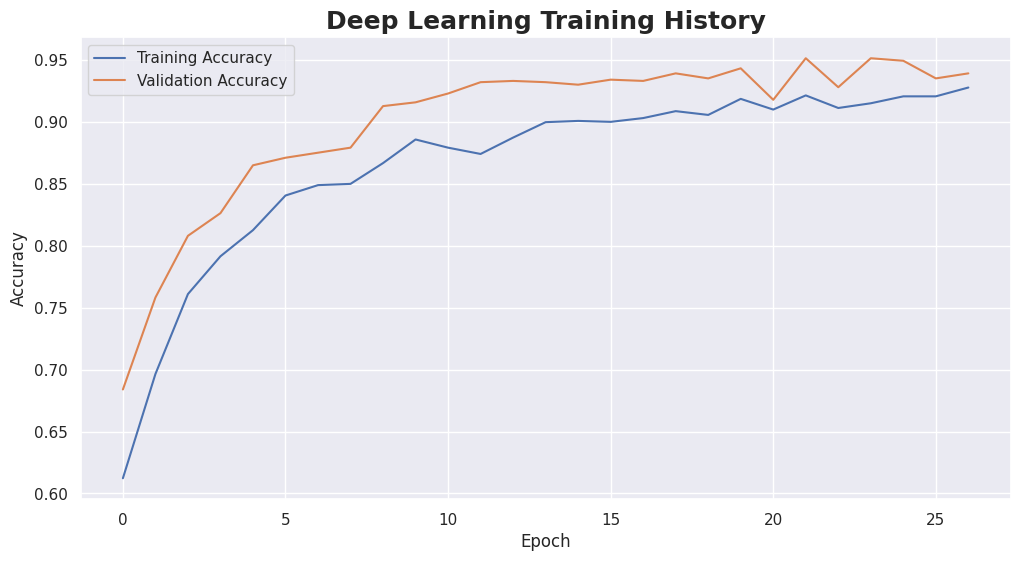

In [32]:

plt.figure(figsize=(12,6))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Deep Learning Training History', fontsize=18, weight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()



# Multi-Planet Systems


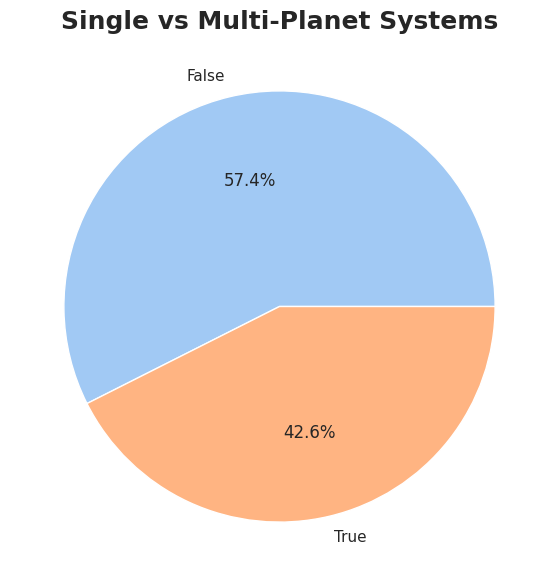

In [33]:

multi_counts = (
    df['multi_planet_system']
      .value_counts()
      .reset_index()
)

multi_counts.columns = ['multi_planet_system', 'count']

plt.figure(figsize=(7,7))

plt.pie(
    multi_counts['count'],
    labels=multi_counts['multi_planet_system'],
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel')
)

plt.title('Single vs Multi-Planet Systems', fontsize=18, weight='bold')

plt.show()



## Analysis and Observations

A significant fraction of host stars contain multiple confirmed planets.

This has several scientific implications:

- Planet formation commonly produces entire planetary systems rather than isolated worlds.
- Multi-planet architectures provide valuable insight into orbital stability and migration dynamics.
- Systems with multiple planets are particularly valuable for comparative planetary science.

The prevalence of multi-planet systems reinforces the idea that planetary formation is a common astrophysical process.



# Spatial Mapping of Exoplanets


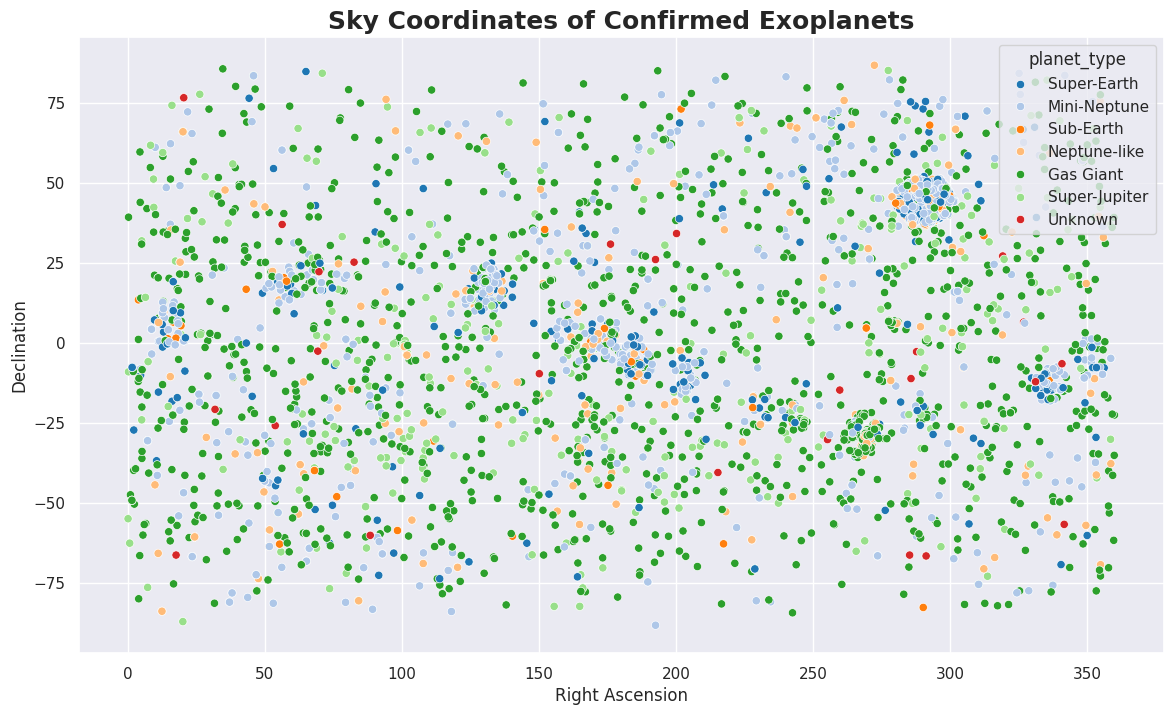

In [34]:

plt.figure(figsize=(14,8))

sns.scatterplot(
    data=df,
    x='ra',
    y='dec',
    hue='planet_type',
    palette='tab20',
    alpha=1
)

plt.title('Sky Coordinates of Confirmed Exoplanets', fontsize=18, weight='bold')
plt.xlabel('Right Ascension')
plt.ylabel('Declination')

plt.show()



## Analysis and Observations

The sky-coordinate distribution reflects the observational footprint of major exoplanet survey missions.

Key observations include:

- Exoplanet detections are not uniformly distributed across the sky.
- Survey geometry and telescope targeting strategies strongly influence detection density.
- Certain sky regions contain concentrated discovery clusters due to dedicated mission coverage.

Spatial visualization provides additional context regarding how observational strategy shapes the known exoplanet catalog.



# Conclusion

The analysis of more than 6,000 confirmed exoplanets reveals how rapidly exoplanet science has evolved into one of the most data-intensive fields in astronomy.

Several major themes emerged throughout the notebook:

- Exoplanet discoveries accelerated dramatically during the Kepler and TESS eras.
- Transit-based detection now dominates the confirmed exoplanet catalog.
- Planetary populations exhibit clear clustering structures across radius, mass, temperature, and orbital distance.
- Stellar environments strongly influence both detectability and planetary characteristics.
- Habitable-zone candidates remain relatively rare within the currently confirmed population.
- Machine learning models successfully learn physically meaningful planetary relationships from observational measurements.
- Deep learning architectures can effectively model high-dimensional astrophysical interactions.

The combination of observational astronomy and modern AI methods creates a powerful framework for future planetary discovery and characterization.

As upcoming observatories continue expanding the confirmed exoplanet catalog, datasets like this will become increasingly important for large-scale astrophysical intelligence systems, automated scientific discovery, and next-generation planetary classification pipelines.

The modern search for worlds beyond Earth is no longer limited by observation alone. Increasingly, it is driven by data, computation, and intelligent systems capable of uncovering structure across the universe at planetary scale.